Setup:

In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.seqlen = model.config.max_position_embeddings

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# from llm import find_layers

# find_layers(model)

# length = 0
# for name, param in model.named_parameters():
#     if 'proj' in name:
#         print(name, param.shape)
#         length += 1
# print(f'Matrix count: {length}')

In [4]:
model.hf_device_map

{'model.embed_tokens': 0,
 'model.layers.0': 0,
 'model.layers.1': 0,
 'model.layers.2': 0,
 'model.layers.3': 0,
 'model.layers.4': 0,
 'model.layers.5': 0,
 'model.layers.6': 0,
 'model.layers.7': 0,
 'model.layers.8': 0,
 'model.layers.9': 0,
 'model.layers.10': 0,
 'model.layers.11': 0,
 'model.layers.12': 0,
 'model.layers.13': 0,
 'model.layers.14': 0,
 'model.layers.15': 0,
 'model.layers.16': 1,
 'model.layers.17': 1,
 'model.layers.18': 1,
 'model.layers.19': 1,
 'model.layers.20': 1,
 'model.layers.21': 1,
 'model.layers.22': 1,
 'model.layers.23': 1,
 'model.layers.24': 1,
 'model.layers.25': 1,
 'model.layers.26': 1,
 'model.layers.27': 1,
 'model.layers.28': 1,
 'model.layers.29': 1,
 'model.layers.30': 1,
 'model.layers.31': 1,
 'model.norm': 1,
 'model.rotary_emb': 1,
 'lm_head': 1}

In [ ]:
q_proj_weight = model.model.layers[7].self_attn.q_proj.weight
print(q_proj_weight.shape)   # torch.Size([1024, 4096])
print(q_proj_weight.device)
print(q_proj_weight.dtype)
print(q_proj_weight)

k_proj_weight = model.model.layers[5].self_attn.k_proj.weight
print(k_proj_weight.shape)   # torch.Size([1024, 4096])
print(k_proj_weight.device)
print(k_proj_weight.dtype)
print(k_proj_weight)

mlp_down_weight = model.model.layers[8].mlp.down_proj.weight
# print(mlp_up_weight.shape)   # torch.Size([14336, 4096])
# print(mlp_up_weight.device)
# print(mlp_up_weight.dtype)
# print(mlp_up_weight)


torch.Size([4096, 4096])
cuda:0
torch.float16
Parameter containing:
tensor([[ 0.0072,  0.0124,  0.0007,  ...,  0.0283,  0.0149,  0.0217],
        [-0.0113,  0.0168, -0.0194,  ..., -0.0437,  0.0007, -0.0057],
        [ 0.0154,  0.0062, -0.0200,  ...,  0.0106, -0.0198, -0.0344],
        ...,
        [ 0.0703, -0.0684,  0.0415,  ..., -0.0762, -0.0120,  0.0060],
        [-0.0801,  0.0388, -0.0036,  ...,  0.0334,  0.0718,  0.0206],
        [-0.0154, -0.0510,  0.0713,  ..., -0.0239, -0.0087, -0.0129]],
       device='cuda:0', dtype=torch.float16, requires_grad=True)
torch.Size([4096, 4096])
cuda:0
torch.float16
Parameter containing:
tensor([[-0.0145,  0.0295,  0.0062,  ...,  0.0155, -0.0024, -0.0049],
        [ 0.0015, -0.0009, -0.0298,  ...,  0.0187, -0.0081,  0.0344],
        [-0.0082, -0.0168,  0.0007,  ...,  0.0046, -0.0104,  0.0037],
        ...,
        [ 0.0073, -0.0007, -0.0234,  ...,  0.0371,  0.0079, -0.0299],
        [ 0.0542,  0.0209, -0.0181,  ..., -0.0014, -0.0156, -0.0361],
  

Tests:

In [6]:
from test_dbsf import *

In [7]:
# a = test_double_sparse(matrix=mlp_down_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [8]:
# b = test_hybrid(matrix=q_proj_weight, asp=0.25, bsp=0.25)

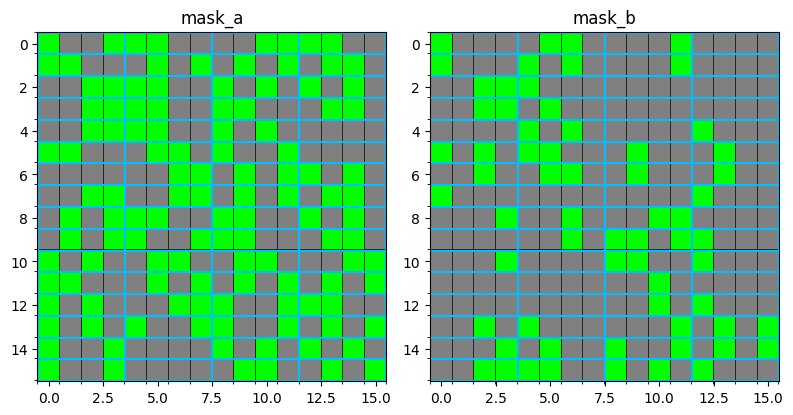

Error pre-finalization:  188.1942596435547
Frobenius pre-finalization:  13.718391418457031
Error post-finalization:  186.4417724609375
Frobenius post-finalization:  13.65436840057373
Sparsity check:  0.4999811053276062
Frobenius norm: 13.65436840057373
A: tensor([[ 0.9016,  0.0000, -0.0000, -0.0408],
        [ 0.0722,  0.6155, -0.0000,  0.0000],
        [-0.0000,  0.0000,  0.7065,  0.1175],
        [ 0.0000, -0.0000,  0.2300,  0.7301]])
B: tensor([[ 0.0102,  0.0000,  0.0000,  0.0000],
        [-0.0164, -0.0000, -0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0498, -0.0057],
        [ 0.0000,  0.0000, -0.0161, -0.0191]])
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
AB: tensor([[-0.0010,  0.0124, -0.0025,  ...,  0.0265,  0.0134,  0.0202],
        [-0.0073,  0.0182, -0.0191,  ..., -0.0421,  0.0011, -0.0020],
        [ 0.0151,  0.0061, -0.0193,  ...,  0.0127, -0.0206, -0.0246],
        ...,
        [ 0.0685, -0.0701,  0.0407,  ..., -0.0756, -0.0149,  0.0066],
  

In [9]:
c = test_2to4_A_B(matrix=q_proj_weight, sp=0.25, mid_dim_scale=1)

In [10]:
# d = test_1x2_2x1(matrix=q_proj_weight, sp=0.25, mid_dim_scale=1)

In [11]:
# e = test_mag_prune(matrix=q_proj_weight, sp=0.5)

In [12]:
# f = test_double_block_sparse(matrix=q_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=2)

In [13]:
# g = test_double_block_sparse(matrix=k_proj_weight, total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [14]:
# h = test_2to4_A_B(matrix=q_proj_weight, sp=0.5, mid_dim_scale=0.5)

Output:

In [15]:
import seaborn as sns
sns.reset_orig()

from matplotlib import rcParams
rcParams['figure.figsize'] = 12.5, 6

outputs = {'dsf': a,
           'hybrid': b, 
           '2:4': c,
           '1x2': d,
           'mag_prune': e,
           'dbsf_2x_mid': f,
           'dbsf': g,
           '2:4_compr': h,
           }
alpha = [1, 0.5, 0.5, 1, 1, 1, 1, 1]

bars = sns.barplot(x = outputs.keys(), y = outputs.values())
bars.tick_params(axis='x', labelsize=12)
for bar, a in zip(bars.containers[0], alpha):
    bar.set_alpha(a)

NameError: name 'a' is not defined

Cleanup:

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()